# Figure 7: Reward-Rate Summary

## What this notebook does

Summarises performance across all three data sets as reward rate (RR) expressed as a
percentage of the ideal-observer RR (computed from simulation). Three panels stacked
vertically, one per data set:

- **Panel 1 — OL (Blocked SNR)**: all 6 raw blocks. Blocks 1–3 = low SNR
  (generative_mean 0.05, SNR ≈ 0.33); blocks 4–6 = high SNR (generative_mean 0.15,
  SNR ≈ 1.0). Ideal RR from 1-D bound sweep.

- **Panel 2 — MX (Mixed SNR)**: all 6 raw blocks. Blocks 1–3 = low+high SNR
  randomly interleaved (generative_means [0.05, 0.15]); blocks 4–6 = medium SNR only
  (generative_mean 0.10, SNR ≈ 0.67). Ideal RR from 1-D bound sweep (single bound
  for both SNR levels, appropriate since subjects cannot know which SNR applies
  trial-by-trial in blocks 1–3).

- **Panel 3 — CP (Change Point)**: 5 blocks.
  - Blocks 1 (Low stable) and 2 (High stable): simulation-based proxy — simulated RR
    at subject's actual bound divided by ideal (maximum) simulated RR.
  - Block 3 (Mixed): no bound data available in pre-computed summaries; shown as NaN.
  - Blocks 4 (Low→High) and 5 (High→Low): per-subject ideal from pre-computed RR matrices
    (`RRMats.mat`), conditioned on subject's pre-CP bound and CP time.

**Data**: OL and MX loaded with `combine_snr=False` (6 raw blocks each). CP from
`boundSummaries_wCP.mat` and `RRMats.mat`.

**Note on CP reward structure**: The simulation for CP stable blocks uses
`BLOCK_DEFAULTS[1]` (no penalty). Update `CP_BLOCK_TYPE` below once the raw CP
CSV files are available to confirm the actual reward structure.

## Imports

In [2]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import scipy.io

from pigeon.data import get_data_table
from pigeon.simulate import get_simulated_data_table
from pigeon.pathDefaults import BOUND_SUMMARIES_FILE, RR_MATS_FILE, FIGURES_DIR

## Load data

Loads OL and MX with `combine_snr=False` to retain all 6 raw blocks per data set.
For OL: blocks 1–3 have a single low SNR; blocks 4–6 have a single high SNR.
For MX: blocks 1–3 interleave low+high SNR; blocks 4–6 use a single medium SNR.

CP data loaded from pre-computed MATLAB files.

In [3]:
data_table_ol = get_data_table(task_type='OL', combine_snr=False)
data_table_mx = get_data_table(task_type='MX', combine_snr=False)

  1: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_14h39.24.096.csv
  2: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_15h37.48.260.csv
  3: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h34.46.761.csv
  4: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h35.25.285.csv
  5: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.33.669.csv
  6: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.41.364.csv
  7: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.49.086.csv
  8: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pi

In [4]:
# --- CP pre-computed summaries ---
mat = scipy.io.loadmat(BOUND_SUMMARIES_FILE, squeeze_me=True, struct_as_record=False)
bs = mat['boundSummaries']

lh_bounds = bs.LowHigh    # (60, 2): col 0 = pre-CP bound, col 1 = post-CP bound
hl_bounds = bs.HighLow
lo_bounds  = bs.Low        # (60, 2): stable Low-SNR bounds; col 0 = mean bound
hi_bounds  = bs.High       # (60, 2): stable High-SNR bounds; col 0 = mean bound
cp_lh = bs.CPLowHigh.astype(int)   # (60,): CP trial index per subject, LowHigh
cp_hl = bs.CPHighLow.astype(int)   # (60,): CP trial index per subject, HighLow

N_CP_SUBJ = int(lh_bounds.shape[0])  # 60

# --- CP reward-rate matrices ---
# pmats[0]: LowHigh  shape (n_pre_bounds, n_post_bounds, n_cp_times) = (16, 16, 21)
# pmats[1]: HighLow  shape (16, 16, 15)
rr_data = scipy.io.loadmat(RR_MATS_FILE, squeeze_me=True, struct_as_record=False)
pmats = list(rr_data['pmats'].flat)

# Bound grid matching MATLAB getPigeon_RRMatrix (0.01 : 0.05 : 0.80)
CP_BOUNDS = np.arange(0.01, 0.81, 0.05)  # 16 values
cp_times  = [np.unique(cp_lh), np.unique(cp_hl)]

print(f'CP subjects: {N_CP_SUBJ}')
print(f'pmats[0] shape (LowHigh): {pmats[0].shape}')
print(f'pmats[1] shape (HighLow): {pmats[1].shape}')
print(f'Unique LowHigh CP times ({len(cp_times[0])}): {cp_times[0]}')
print(f'Unique HighLow CP times ({len(cp_times[1])}): {cp_times[1]}')

CP subjects: 60
pmats[0] shape (LowHigh): (16, 16, 21)
pmats[1] shape (HighLow): (16, 16, 15)
Unique LowHigh CP times (21): [ 3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 21 26 29 37]
Unique HighLow CP times (15): [ 3  4  5  6  7  8  9 10 11 12 13 14 15 16 48]


## Simulation parameters and helper

`compute_ideal_rr_curve` sweeps `bound_mean` over `SIM_BOUNDS` and returns median
total-coins/600 per bound value. The maximum of the curve is used as the ideal RR
for that block.

In [5]:
SIM_BOUNDS    = np.arange(0.01, 0.76, 0.01)   # 75 bound values
NUM_SIM_SUBJ  = 100
rng = np.random.default_rng(0)                 # fixed seed for reproducibility

# OL: blocks 1-3 = low SNR (g_mean=0.05), blocks 4-6 = high SNR (g_mean=0.15)
OL_BLOCKS = [1, 2, 3, 4, 5, 6]
OL_GMEANS = [0.05, 0.05, 0.05, 0.15, 0.15, 0.15]

# MX: blocks 1-3 = mixed low+high SNR (single bound sweeps with interleaved trials),
#     blocks 4-6 = single medium SNR (g_mean=0.10)
MX_BLOCKS = [1, 2, 3, 4, 5, 6]
MX_GMEANS = [[0.05, 0.15], [0.05, 0.15], [0.05, 0.15], 0.10, 0.10, 0.10]

# CP stable blocks: BLOCK_DEFAULTS[1] (no penalty) assumed.
# Update CP_BLOCK_TYPE once raw CP CSV files confirm the actual reward structure.
CP_BLOCK_TYPE = 1


def compute_ideal_rr_curve(block, generative_mean, sim_bounds, num_sim_subj, rng):
    """
    Sweep bound_mean over sim_bounds; return array of median total_coins/600.
    Maximum is the ideal reward rate for this block configuration.
    """
    rr_curve = np.full(len(sim_bounds), np.nan)
    for i, bnd in enumerate(sim_bounds):
        if i % 15 == 0:
            print(f'  bound {i + 1}/{len(sim_bounds)}', end='\r')
        sim = get_simulated_data_table(
            specs={'num_subjects': num_sim_subj, 'blocks': block},
            generative_mean=generative_mean,
            bound_mean=float(bnd),
            rng=rng,
        )
        coins = sim.groupby('subject_index')['coin_count'].last().to_numpy()
        rr_curve[i] = float(np.nanmedian(coins)) / 600
    print()
    return rr_curve

## Simulate ideal RR — OL blocks 1–6

Blocks 1–3 use low SNR (g_mean=0.05); blocks 4–6 use high SNR (g_mean=0.15).
Each block uses the corresponding `BLOCK_DEFAULTS` reward structure.

In [6]:
ol_ideal_rr  = np.full(6, np.nan)
ol_rr_curves = []

for bi, (block, gm) in enumerate(zip(OL_BLOCKS, OL_GMEANS)):
    print(f'OL block {block} (g_mean={gm})...')
    curve = compute_ideal_rr_curve(block, gm, SIM_BOUNDS, NUM_SIM_SUBJ, rng)
    ol_rr_curves.append(curve)
    ol_ideal_rr[bi] = float(np.nanmax(curve))
    print(f'  ideal RR = {ol_ideal_rr[bi]:.4f}')

print('\nOL ideal RR by block:', np.round(ol_ideal_rr, 4))

OL block 1 (g_mean=0.05)...
  bound 61/75
  ideal RR = 0.2483
OL block 2 (g_mean=0.05)...
  bound 61/75
  ideal RR = 0.0600
OL block 3 (g_mean=0.05)...
  bound 61/75
  ideal RR = 0.0767
OL block 4 (g_mean=0.15)...
  bound 61/75
  ideal RR = 0.3350
OL block 5 (g_mean=0.15)...
  bound 61/75
  ideal RR = 0.2483
OL block 6 (g_mean=0.15)...
  bound 61/75
  ideal RR = 0.2367

OL ideal RR by block: [0.2483 0.06   0.0767 0.335  0.2483 0.2367]


## Simulate ideal RR — MX blocks 1–6

Blocks 1–3: `generative_mean=[0.05, 0.15]` → trials from both SNR levels are randomly
interleaved; a single `bound_mean` applies to all trials (appropriate benchmark since
subjects cannot identify which SNR applies on each trial).
Blocks 4–6: single medium SNR (g_mean=0.10).

In [7]:
mx_ideal_rr  = np.full(6, np.nan)
mx_rr_curves = []

for bi, (block, gm) in enumerate(zip(MX_BLOCKS, MX_GMEANS)):
    print(f'MX block {block} (g_mean={gm})...')
    curve = compute_ideal_rr_curve(block, gm, SIM_BOUNDS, NUM_SIM_SUBJ, rng)
    mx_rr_curves.append(curve)
    mx_ideal_rr[bi] = float(np.nanmax(curve))
    print(f'  ideal RR = {mx_ideal_rr[bi]:.4f}')

print('\nMX ideal RR by block:', np.round(mx_ideal_rr, 4))

MX block 1 (g_mean=[0.05, 0.15])...
  bound 61/75
  ideal RR = 0.2917
MX block 2 (g_mean=[0.05, 0.15])...
  bound 61/75
  ideal RR = 0.1117
MX block 3 (g_mean=[0.05, 0.15])...
  bound 61/75
  ideal RR = 0.1167
MX block 4 (g_mean=0.1)...
  bound 61/75
  ideal RR = 0.2983
MX block 5 (g_mean=0.1)...
  bound 61/75
  ideal RR = 0.1600
MX block 6 (g_mean=0.1)...
  bound 61/75
  ideal RR = 0.1550

MX ideal RR by block: [0.2917 0.1117 0.1167 0.2983 0.16   0.155 ]


## Actual RR and OL/MX performance

For each (subject, block), `actual_RR = last_coin_count / 600`.
Performance = actual_RR / ideal_RR × 100 %.

In [8]:
def get_rr_array(data_table, blocks):
    """Return (subjects, rr) where rr has shape (n_subjects, n_blocks)."""
    subjects = np.sort(data_table['subject_index'].dropna().unique())
    dt = data_table.sort_values('trial_number')
    rr = np.full((len(subjects), len(blocks)), np.nan)
    for si, subj in enumerate(subjects):
        for bi, block in enumerate(blocks):
            ls = (dt['subject_index'] == subj) & (dt['block_index'] == block)
            coins = dt.loc[ls, 'coin_count'].dropna()
            if len(coins):
                rr[si, bi] = float(coins.iloc[-1]) / 600
    return subjects, rr


subjects_ol, ol_actual_rr = get_rr_array(data_table_ol, OL_BLOCKS)
subjects_mx, mx_actual_rr = get_rr_array(data_table_mx, MX_BLOCKS)

ol_perf = ol_actual_rr / ol_ideal_rr[None, :] * 100   # (n_ol, 6)
mx_perf = mx_actual_rr / mx_ideal_rr[None, :] * 100   # (n_mx, 6)

print(f'OL: {len(subjects_ol)} subjects')
print(f'  median % ideal by block: {np.round(np.nanmedian(ol_perf, axis=0), 1)}')
print(f'MX: {len(subjects_mx)} subjects')
print(f'  median % ideal by block: {np.round(np.nanmedian(mx_perf, axis=0), 1)}')

OL: 60 subjects
  median % ideal by block: [ 54.7 -12.5  69.6  66.4  57.4  57.4]
MX: 60 subjects
  median % ideal by block: [56.9 39.6 71.4 65.1 58.9 66.7]


## CP performance (simulation-based proxy)

**Stable blocks (Low, High)**: simulate a 1-D RR curve at the appropriate SNR; for each
subject, interpolate their RR at their actual bound (from `boundSummaries_wCP.mat`,
column 0). Ideal = maximum of simulated curve.

**Mixed block**: no bound data available in pre-computed summaries → all NaN.

**Transition blocks (Low→High, High→Low)**: use pre-computed RR matrices. For each
subject, the relevant slice of the matrix is indexed by (pre-CP bound, CP time). Ideal
= maximum over post-CP bounds in that slice; actual proxy = value at subject's
post-CP bound.

In [9]:
# --- Stable Low (CP block 1) ---
print(f'CP stable Low (g_mean=0.05, block type={CP_BLOCK_TYPE})...')
cp_lo_curve = compute_ideal_rr_curve(CP_BLOCK_TYPE, 0.05, SIM_BOUNDS, NUM_SIM_SUBJ, rng)
cp_lo_ideal = float(np.nanmax(cp_lo_curve))
print(f'  ideal RR = {cp_lo_ideal:.4f}')

# --- Stable High (CP block 2) ---
print(f'CP stable High (g_mean=0.15, block type={CP_BLOCK_TYPE})...')
cp_hi_curve = compute_ideal_rr_curve(CP_BLOCK_TYPE, 0.15, SIM_BOUNDS, NUM_SIM_SUBJ, rng)
cp_hi_ideal = float(np.nanmax(cp_hi_curve))
print(f'  ideal RR = {cp_hi_ideal:.4f}')


def stable_cp_perf(actual_bounds, rr_curve, ideal_rr, sim_bounds):
    """Simulation proxy: interpolate simulated RR at each subject's actual bound."""
    perf = np.full(len(actual_bounds), np.nan)
    for pp, bnd in enumerate(actual_bounds):
        if np.isfinite(bnd) and bnd > 0:
            rr_at_bnd = float(np.interp(bnd, sim_bounds, rr_curve))
            perf[pp] = rr_at_bnd / ideal_rr * 100
    return perf


cp_perf_lo = stable_cp_perf(lo_bounds[:, 0], cp_lo_curve, cp_lo_ideal, SIM_BOUNDS)
cp_perf_hi = stable_cp_perf(hi_bounds[:, 0], cp_hi_curve, cp_hi_ideal, SIM_BOUNDS)

print(f'\nCP Low  median % ideal: {np.nanmedian(cp_perf_lo):.1f}')
print(f'CP High median % ideal: {np.nanmedian(cp_perf_hi):.1f}')

CP stable Low (g_mean=0.05, block type=1)...
  bound 61/75
  ideal RR = 0.2500
CP stable High (g_mean=0.15, block type=1)...
  bound 61/75
  ideal RR = 0.3367

CP Low  median % ideal: 78.5
CP High median % ideal: 87.7


In [10]:
# --- Mixed block (CP block 3): no bound data available ---
cp_perf_mixed = np.full(N_CP_SUBJ, np.nan)


# --- Transition blocks (CP blocks 4 and 5) ---
def cp_transition_perf(pre_bounds, post_bounds, cp_times_subj, pmat, cp_times_grid):
    """
    Per-subject performance from pre-computed RR matrix.
    Ideal = max over post-CP bounds at (pre-CP bound, CP time) slice.
    Actual proxy = matrix value at subject's actual post-CP bound.
    """
    perf = np.full(len(pre_bounds), np.nan)
    for pp in range(len(pre_bounds)):
        pre_b  = pre_bounds[pp]
        post_b = post_bounds[pp]
        cp_t   = int(cp_times_subj[pp])
        if not (np.isfinite(pre_b) and np.isfinite(post_b)):
            continue
        cp_idx_arr = np.where(cp_times_grid == cp_t)[0]
        if not len(cp_idx_arr):
            continue
        cp_idx = int(cp_idx_arr[0])
        prei  = int(np.clip(np.searchsorted(CP_BOUNDS, pre_b,  'right') - 1,
                            0, len(CP_BOUNDS) - 1))
        posti = int(np.clip(np.searchsorted(CP_BOUNDS, post_b, 'right') - 1,
                            0, len(CP_BOUNDS) - 1))
        rrs   = pmat[prei, :, cp_idx]
        ideal = float(np.nanmax(rrs))
        if ideal > 0 and np.isfinite(rrs[posti]):
            perf[pp] = rrs[posti] / ideal * 100
    return perf


cp_perf_lh = cp_transition_perf(
    lh_bounds[:, 0], lh_bounds[:, 1], cp_lh, pmats[0], cp_times[0])
cp_perf_hl = cp_transition_perf(
    hl_bounds[:, 0], hl_bounds[:, 1], cp_hl, pmats[1], cp_times[1])

# Stack: columns = [Low, High, Mixed, LowHigh, HighLow]  (CP blocks 1-5)
cp_perf = np.column_stack([cp_perf_lo, cp_perf_hi, cp_perf_mixed, cp_perf_lh, cp_perf_hl])

print('CP performance shape:', cp_perf.shape)
print('Median % ideal by block:', np.round(np.nanmedian(cp_perf, axis=0), 1))

CP performance shape: (60, 5)
Median % ideal by block: [78.5 87.7  nan 81.4 95.1]


/var/folders/tp/dghl0fxd0wg0rsyq4p4tzcnc0000gn/T/ipykernel_72295/800458324.py:43: RuntimeWarning: All-NaN slice encountered
  print('Median % ideal by block:', np.round(np.nanmedian(cp_perf, axis=0), 1))


## Figure

Three panels stacked vertically. Each shows a scatter of % ideal RR vs. task block;
one point per participant. Dashed horizontal line at 100 % (ideal-observer level).
Light jitter on x for visibility.

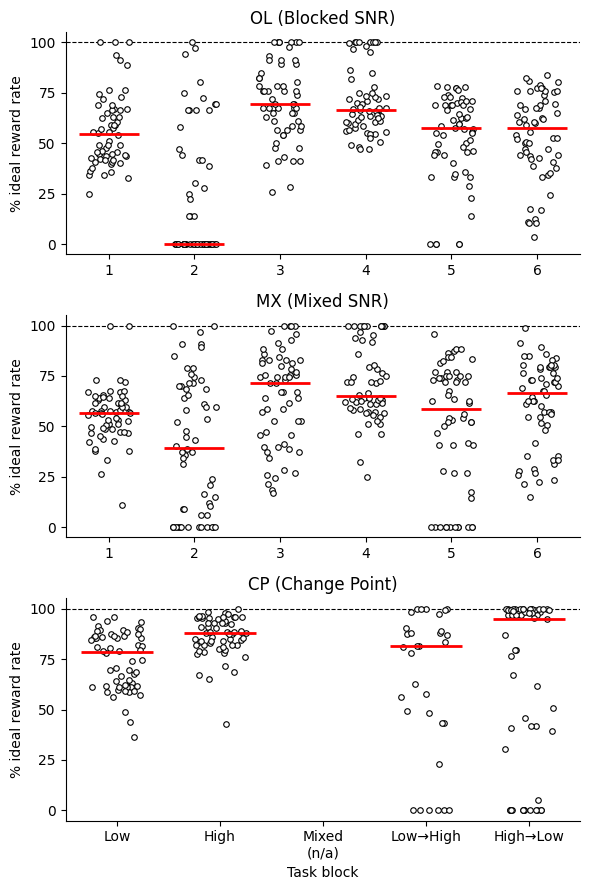

In [11]:
rng_jitter = np.random.default_rng(99)

MARKER_KW = dict(
    marker='o', markerfacecolor='white', markeredgecolor='k',
    markeredgewidth=0.8, markersize=4, linestyle='none',
)
Y_PAD = 5   # axis padding beyond [0, 100] so clipped points show in full


def plot_rr_panel(ax, perf, n_blocks, block_labels=None, title=''):
    """
    Scatter % ideal RR vs. block for all subjects.
    Values are clipped to [0, 100]; y axis extends Y_PAD units beyond each end
    so clipped markers are fully visible. Red horizontal bars show per-block medians.
    perf : (n_subjects, n_blocks) array.
    """
    for bi in range(n_blocks):
        col   = perf[:, bi]
        valid = np.isfinite(col)
        if not valid.any():
            continue
        clipped = np.clip(col[valid], 0, 100)
        jx = (bi + 1) + rng_jitter.uniform(-0.25, 0.25, size=valid.sum())
        ax.plot(jx, clipped, **MARKER_KW)
        # Median bar
        med = float(np.nanmedian(clipped))
        ax.plot([bi + 0.65, bi + 1.35], [med, med],
                '-', color='red', linewidth=2, zorder=5, solid_capstyle='butt')
    ax.axhline(100, color='k', linestyle='--', linewidth=0.8, zorder=0)
    ax.set_xlim(0.5, n_blocks + 0.5)
    ax.set_ylim(-Y_PAD, 100 + Y_PAD)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_xticks(range(1, n_blocks + 1))
    if block_labels is not None:
        ax.set_xticklabels(block_labels)
    ax.set_ylabel('% ideal reward rate')
    ax.set_title(title)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)


fig, axs = plt.subplots(3, 1, figsize=(6, 9))

plot_rr_panel(axs[0], ol_perf, 6, title='OL (Blocked SNR)')
plot_rr_panel(axs[1], mx_perf, 6, title='MX (Mixed SNR)')
plot_rr_panel(
    axs[2], cp_perf, 5,
    block_labels=['Low', 'High', 'Mixed\n(n/a)', 'Low→High', 'High→Low'],
    title='CP (Change Point)',
)

axs[2].set_xlabel('Task block')
plt.tight_layout()
plt.show()

## Formatted figure

Publication-quality version. Saves to `Figure07_RRSummary_formatted.pdf`.

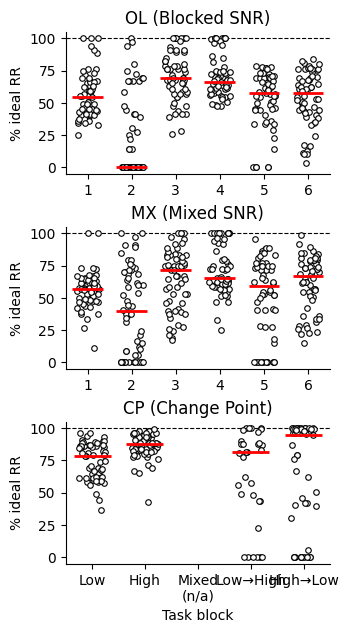

Saved /Users/jigold/Library/CloudStorage/Box-Box/GoldLab/Projects/2025_Pigeon/Figures/Figure07_RRSummary_formatted.pdf


In [12]:
import matplotlib.gridspec as gridspec

CM  = 1 / 2.54
WID = 8.5
HTS = [4.0, 4.0, 4.0]
PSH = 1.5
FS  = 12

fig_h   = sum(HTS) + PSH * (len(HTS) - 1)
panel_h = np.mean(HTS)
hspace  = PSH / panel_h

fig_fmt = plt.figure(figsize=(WID * CM, fig_h * CM))
gs = gridspec.GridSpec(
    3, 1, figure=fig_fmt,
    hspace=hspace,
    left=0.18, right=0.97, bottom=0.07, top=0.97,
)
axs_fmt = [fig_fmt.add_subplot(gs[r]) for r in range(3)]

plt.rcParams.update({'font.size': FS, 'axes.labelsize': FS, 'axes.titlesize': FS})

rng_jitter_fmt = np.random.default_rng(99)


def plot_rr_panel_fmt(ax, perf, n_blocks, block_labels=None, title=''):
    for bi in range(n_blocks):
        col   = perf[:, bi]
        valid = np.isfinite(col)
        if not valid.any():
            continue
        clipped = np.clip(col[valid], 0, 100)
        jx = (bi + 1) + rng_jitter_fmt.uniform(-0.25, 0.25, size=valid.sum())
        ax.plot(jx, clipped, **MARKER_KW)
        med = float(np.nanmedian(clipped))
        ax.plot([bi + 0.65, bi + 1.35], [med, med],
                '-', color='red', linewidth=2, zorder=5, solid_capstyle='butt')
    ax.axhline(100, color='k', linestyle='--', linewidth=0.8, zorder=0)
    ax.set_xlim(0.5, n_blocks + 0.5)
    ax.set_ylim(-Y_PAD, 100 + Y_PAD)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_xticks(range(1, n_blocks + 1))
    if block_labels is not None:
        ax.set_xticklabels(block_labels, fontsize=FS - 2)
    ax.set_ylabel('% ideal RR')
    ax.set_title(title)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)


plot_rr_panel_fmt(axs_fmt[0], ol_perf, 6, title='OL (Blocked SNR)')
plot_rr_panel_fmt(axs_fmt[1], mx_perf, 6, title='MX (Mixed SNR)')
plot_rr_panel_fmt(
    axs_fmt[2], cp_perf, 5,
    block_labels=['Low', 'High', 'Mixed\n(n/a)', 'Low→High', 'High→Low'],
    title='CP (Change Point)',
)
axs_fmt[2].set_xlabel('Task block')

out = FIGURES_DIR / 'Figure07_RRSummary_formatted.pdf'
fig_fmt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {out}')